In [1]:
from BEM import*

%load_ext autoreload
%autoreload 2

In [2]:
import casadi as ca
    
x  = ca.SX.sym('x')
y  = ca.SX.sym('y')

c0 = 0.0025 # mm
n = 0
R2 = 25
c = 2 ** n * c0
R1 = R2 - c

# surface 1: top surface
f1_expr = ca.if_else( x**2 + y **2 < R1 ** 2, - (-y**2 - x**2 + R1**2)**(0.5), R1*0.3)
f1 = ca.Function('f1', [x, y], [f1_expr])
f1_dx = ca.jacobian(f1_expr, x)
f1_dy = ca.jacobian(f1_expr, y)
n1_expr = ca.vertcat(-f1_dx, -f1_dy, 1)
n1_expr = n1_expr / ca.norm_2(n1_expr)
n1_fun = ca.Function('n1', [x, y], [n1_expr])
surface1 = {'point': lambda x,y: f1(x,y).full(), 'normal': lambda x,y: n1_fun(x,y).full()}

# surface 2: bottom surface
f2_expr = ca.if_else( x**2 + y **2 < R2 ** 2, - (-y**2 - x**2 + R2**2)**(0.5), 0)
f2 = ca.Function('f2', [x, y], [f2_expr])
f2_dx = ca.jacobian(f2_expr, x)
f2_dy = ca.jacobian(f2_expr, y)
n2_expr = ca.vertcat(-f2_dx, -f2_dy, 1)
n2_expr = n2_expr / ca.norm_2(n2_expr)
n2_fun = ca.Function('n2', [x, y], [n2_expr])
surface2 = {'point': lambda x,y: f2(x,y).full(), 'normal': lambda x,y: n2_fun(x,y).full()}
  


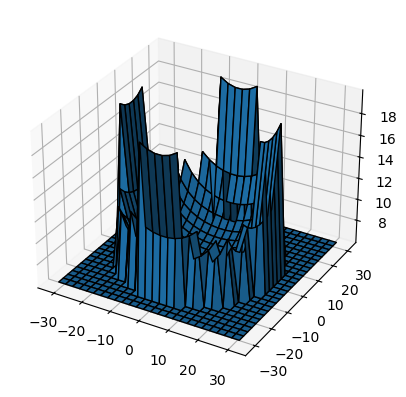

c:\Users\egrab\miniconda3\envs\researchCode\Lib\site-packages\qpsolvers\conversions\ensure_sparse_matrices.py:24: UserWarning: Converted P to scipy.sparse.csc.csc_matrix
For best performance, build P as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(
c:\Users\egrab\miniconda3\envs\researchCode\Lib\site-packages\qpsolvers\conversions\ensure_sparse_matrices.py:24: UserWarning: Converted G to scipy.sparse.csc.csc_matrix
For best performance, build G as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(
c:\Users\egrab\miniconda3\envs\researchCode\Lib\site-packages\qpsolvers\conversions\ensure_sparse_matrices.py:24: UserWarning: Converted A to scipy.sparse.csc.csc_matrix
For best performance, build A as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(


Elapsed time:  0.35166287422180176


In [3]:
material_properties = {'E1': 200e3, 'E2': 200e3, 'ni1': 0.3, 'ni2': 0.3, 'f': 0.0}
mesh = {'hx': R2/10, 'hy': R2/10, 'w_x': 2.5*R1, 'w_y': 2.5*R1}
load = 2000 # N
sol, S1, S2, z1, z2, x, y = simulate_bem(surface1, surface2, load, material_properties, mesh, use_normals = False, solver ='osqp')   #solver = 'cvxopt', abstol = 1e-10, feastol = 1e-10, reltol = 1e-10

In [4]:
%matplotlib qt
rigid_body_displacement, area, pmax, p, delta = post_processing(sol, S1, S2, z1, z2, x, y, mesh)
print('displacement: ', delta)
print('Rigid body displacement: ', rigid_body_displacement)
print('Contact area: ', area)
print('Max pressure: ', pmax)
print(p/pmax)

displacement:  0.002446500302639163
Rigid body displacement:  0.003215444107889425
Contact area:  4225.0
Max pressure:  0.47339545236213
[[0.9999404  0.99994043 0.9999407  0.99994111 0.9999416  0.99994215
  0.99994274 0.99994333 0.9999439  0.99994442 0.99994484 0.99994514
  0.9999453  0.9999453  0.99994514 0.99994484 0.99994441 0.9999439
  0.99994333 0.99994274 0.99994215 0.9999416  0.99994111 0.9999407
  0.99994043 0.9999404 ]
 [0.99994043 0.99994044 0.99994075 0.99994124 0.99994185 0.99994255
  0.9999433  0.99994408 0.99994483 0.99994553 0.99994611 0.99994653
  0.99994675 0.99994675 0.99994653 0.99994611 0.99994553 0.99994483
  0.99994408 0.9999433  0.99994255 0.99994185 0.99994124 0.99994075
  0.99994043 0.99994043]
 [0.9999407  0.99994075 0.99994115 0.99994176 0.99994253 0.99994343
  0.9999444  0.99994541 0.99994643 0.99994741 0.99994827 0.99994888
  0.99994919 0.99994919 0.99994888 0.99994827 0.9999474  0.99994643
  0.99994541 0.99994439 0.99994342 0.99994253 0.99994176 0.99994114

c:\Users\egrab\miniconda3\envs\researchCode\Lib\site-packages\mplcursors\_pick_info.py:142: UserWarning: Pick support for Poly3DCollection is missing.
  warnings.warn(f"Pick support for {type(artist).__name__} is missing.")


In [6]:
from numpy import array, dot
from qpsolvers import solve_qp

M = array([[1., 2., 0.], [-8., 3., 2.], [0., 1., 1.]])
P = dot(M.T, M)  # quick way to build a symmetric matrix
q = dot(array([3., 2., 3.]), M).reshape((3,))
G = array([[1., 2., 1.], [2., 0., 1.], [-1., 2., -1.]])
h = array([3., 2., -2.]).reshape((3,))
A = array([1., 1., 1.])
b = array([1.])

x = solve_qp(P, q, G, h, A, b, solver="osqp")
print(f"QP solution: x = {x}")


QP solution: x = [ 0.3076548  -0.69232615  1.38448776]


c:\Users\egrab\miniconda3\envs\researchCode\Lib\site-packages\qpsolvers\conversions\ensure_sparse_matrices.py:24: UserWarning: Converted P to scipy.sparse.csc.csc_matrix
For best performance, build P as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(
c:\Users\egrab\miniconda3\envs\researchCode\Lib\site-packages\qpsolvers\conversions\ensure_sparse_matrices.py:24: UserWarning: Converted G to scipy.sparse.csc.csc_matrix
For best performance, build G as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(
c:\Users\egrab\miniconda3\envs\researchCode\Lib\site-packages\qpsolvers\conversions\ensure_sparse_matrices.py:24: UserWarning: Converted A to scipy.sparse.csc.csc_matrix
For best performance, build A as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(
